In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [5]:

# ------------------------------------------------------------------
# CONFIGURACIÓN: editá estas tres variables según lo que necesites
# ------------------------------------------------------------------
ARCHIVO = "UTILITY.xls"          # nombre (o ruta) del archivo Excel
COLUMNA = "Utility Charge"              # nombre de la columna a analizar
CANTIDAD_INTERVALOS = 5         # cantidad de intervalos de la tabla
# ------------------------------------------------------------------


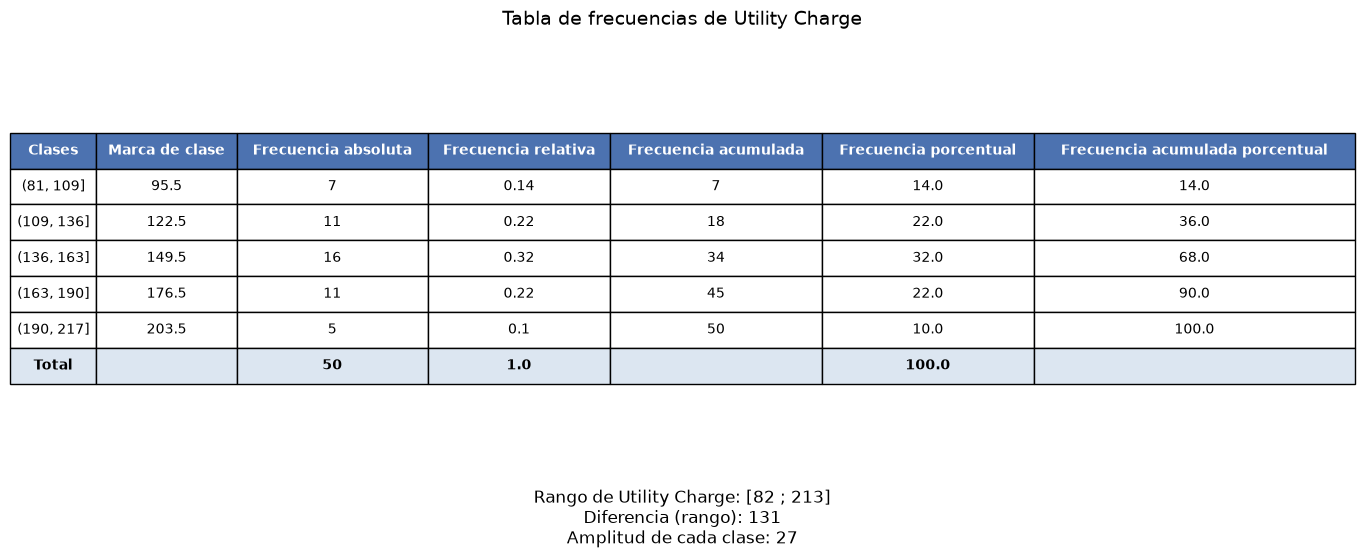

In [7]:
import math
import numpy as np


def generar_tabla_frecuencias(archivo: str, columna: str, cantidad_intervalos: int):
    if cantidad_intervalos <= 0:
        raise ValueError("La cantidad de intervalos debe ser mayor que cero.")

    ruta = archivo if os.path.isabs(archivo) else os.path.join(os.getcwd(), archivo)

    if not os.path.exists(ruta):
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")

    df = pd.read_excel(ruta)

    if columna not in df.columns:
        raise ValueError(
            f"La columna '{columna}' no existe en el archivo. "
            f"Columnas disponibles: {list(df.columns)}"
        )

    datos = pd.to_numeric(df[columna], errors="coerce").dropna()

    if datos.empty:
        raise ValueError(f"La columna '{columna}' no tiene datos numéricos.")

    minimo = math.floor(datos.min())
    maximo = math.ceil(datos.max())
    rango = maximo - minimo

    if rango == 0:
        amplitud = 1
    else:
        amplitud = max(1, math.ceil(rango / cantidad_intervalos))

    extremo_final = minimo + (amplitud * cantidad_intervalos)
    if extremo_final < maximo:
        extremo_final = maximo + amplitud

    bordes = np.arange(minimo, extremo_final + 1, amplitud, dtype=float)
    intervalos, bordes = pd.cut(datos, bins=bordes, include_lowest=True, retbins=True)
    conteo = intervalos.value_counts(sort=False).sort_index()

    tabla = pd.DataFrame({
        "Clases": [f"({int(i.left)}, {int(i.right)}]" for i in conteo.index],
        "Marca de clase": [int(i.mid) if float(i.mid).is_integer() else round(float(i.mid), 2) for i in conteo.index],
        "Frecuencia absoluta": conteo.values.astype(int),
    })

    tabla["Frecuencia relativa"] = (tabla["Frecuencia absoluta"] / tabla["Frecuencia absoluta"].sum()).round(2)
    tabla["Frecuencia acumulada"] = tabla["Frecuencia absoluta"].cumsum()
    tabla["Frecuencia porcentual"] = (tabla["Frecuencia relativa"] * 100).round(2)
    tabla["Frecuencia acumulada porcentual"] = tabla["Frecuencia porcentual"].cumsum().round(2)

    fila_total = {
        "Clases": "Total",
        "Marca de clase": "",
        "Frecuencia absoluta": int(tabla["Frecuencia absoluta"].sum()),
        "Frecuencia relativa": round(float(tabla["Frecuencia relativa"].sum()), 2),
        "Frecuencia acumulada": "",
        "Frecuencia porcentual": round(float(tabla["Frecuencia porcentual"].sum()), 2),
        "Frecuencia acumulada porcentual": "",
    }
    tabla = pd.concat([tabla, pd.DataFrame([fila_total])], ignore_index=True)

    return tabla, float(minimo), float(maximo), float(amplitud)


def graficar_tabla(tabla: pd.DataFrame, columna: str, minimo: float, maximo: float, amplitud: float):
    fig = plt.figure(figsize=(12, 0.45 * len(tabla) + 3))
    gs = gridspec.GridSpec(2, 1, height_ratios=[len(tabla) + 1.5, 1], figure=fig)

    ax_tabla = fig.add_subplot(gs[0])
    ax_tabla.axis("off")

    tabla_mpl = ax_tabla.table(
        cellText=tabla.values,
        colLabels=tabla.columns,
        cellLoc="center",
        loc="center",
    )
    tabla_mpl.auto_set_font_size(False)
    tabla_mpl.set_fontsize(10)
    tabla_mpl.scale(1, 1.8)
    tabla_mpl.auto_set_column_width(col=list(range(len(tabla.columns))))

    for (fila, _col), celda in tabla_mpl.get_celld().items():
        celda.set_edgecolor("black")
        if fila == 0:
            celda.set_facecolor("#4C72B0")
            celda.set_text_props(color="white", weight="bold")
        elif tabla.iloc[fila - 1]["Clases"] == "Total":
            celda.set_facecolor("#DCE6F1")
            celda.set_text_props(weight="bold")

    ax_texto = fig.add_subplot(gs[1])
    ax_texto.axis("off")
    rango_total = int(maximo) - int(minimo)
    texto = (
        f"Rango de {columna}: [{int(minimo)} ; {int(maximo)}]\n"
        f"Diferencia (rango): {rango_total}\n"
        f"Amplitud de cada clase: {int(amplitud)}"
    )
    ax_texto.text(0.5, 0.5, texto, ha="center", va="center", fontsize=12)

    fig.suptitle(f"Tabla de frecuencias de {columna}", fontsize=14)
    plt.tight_layout()
    plt.show()


def main():
    tabla, minimo, maximo, amplitud = generar_tabla_frecuencias(ARCHIVO, COLUMNA, CANTIDAD_INTERVALOS)
    graficar_tabla(tabla, COLUMNA, minimo, maximo, amplitud)


if __name__ == "__main__":
    main()
